# JusticeCast — Phase 5 Comparative Evaluation

**Two-track methodology study: bag-of-words vs pre-trained sentence embeddings.**
Same fold-0 test set (`src/modeling/splits.py`), same evaluation harness, same Justices.

This notebook walks through:
1. Top-line comparison (test ROC AUC, CV vs test gap, the +3.7 pp finding)
2. Standard suite — confusion matrices, ROC curves, PR curves, calibration curves
3. **The honesty triad** (Non-Negotiable #13): per-Justice AUC under three slicings — global, unanimous, contested-only
4. Per-Justice lift over individual baselines (Non-Negotiable #12)
5. Embeddings interpretation via extreme-score utterances
6. The reframed business interpretation

Inputs from `reports/results/phase5_*.csv`, generated by `python -m src.phase5_evaluation`.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

R = ROOT / 'reports/results'
summary = pd.read_csv(R / 'phase5_summary_metrics.csv')
roc_data = pd.read_csv(R / 'phase5_roc_curve_data.csv')
pr_data = pd.read_csv(R / 'phase5_pr_curve_data.csv')
cal_data = pd.read_csv(R / 'phase5_calibration_data.csv')
cm_data = pd.read_csv(R / 'phase5_confusion_matrices.csv')
triad = pd.read_csv(R / 'phase5_honesty_triad.csv')
lift = pd.read_csv(R / 'phase5_per_justice_lift.csv')
preds = pd.read_csv(R / 'phase5_test_predictions.csv')
extremes = pd.read_csv(R / 'phase5_extreme_utterances.csv')

# Phase 4 + 4.5 GridSearchCV stats
phase4_eval = pd.read_csv(R / 'phase4_test_eval.csv')
phase45_eval = pd.read_csv(R / 'phase45_test_eval.csv')

print(f'Loaded {len(preds):,} test-row predictions across both tracks')

Loaded 2,007 test-row predictions across both tracks


## 1. Top-line — the +3.7 pp finding

Both tracks use the same fold-0 test set (2,007 rows, 258 cases). Both vectorizers/encoders have been tuned via 5-fold cross-validated GridSearchCV on the 8,032-row train set. Refit on full train, evaluated on test.

The headline reframing: **a lightweight pre-trained MiniLM (384-dim, ~80MB, no fine-tuning) beats a tuned 200K-feature TF-IDF + LinearSVC by 3.7 percentage points of ROC AUC**. That gap is 9× the entire Phase 4 BoW tuning gain (+0.4 pp). The bench-questioning text contains semantic structure that bag-of-words representations cannot access.

In [2]:
topline_rows = []
for track in ['bow', 'embeddings']:
    s_eval = phase4_eval if track == 'bow' else phase45_eval
    best_eval = s_eval.loc[s_eval['test_roc_auc'].idxmax()]
    final = summary[summary['track'] == track].iloc[0]
    topline_rows.append({
        'track': 'BoW (TF-IDF + LinearSVC, tuned)' if track == 'bow' else 'Embeddings (MiniLM-384 + LogReg, tuned)',
        'CV ROC AUC (5-fold mean)': best_eval['best_cv_score'],
        'Test ROC AUC (fold 0)': final['test_roc_auc'],
        'CV-test gap': best_eval['cv_test_gap'],
        'Test balanced acc.': final['test_balanced_accuracy'],
        'Test F1': final['test_f1'],
    })
topline = pd.DataFrame(topline_rows)
print(topline.to_string(index=False, float_format='%.4f'))
print(f"\nLift (embeddings - BoW), test AUC: +{topline.iloc[1]['Test ROC AUC (fold 0)'] - topline.iloc[0]['Test ROC AUC (fold 0)']:+.4f}")

                                  track  CV ROC AUC (5-fold mean)  Test ROC AUC (fold 0)  CV-test gap  Test balanced acc.  Test F1
        BoW (TF-IDF + LinearSVC, tuned)                    0.5402                 0.5323       0.0079              0.5319   0.5984
Embeddings (MiniLM-384 + LogReg, tuned)                    0.5398                 0.5691      -0.0293              0.5503   0.5989

Lift (embeddings - BoW), test AUC: ++0.0368


**Reading the CV-test gap.** BoW has a tiny positive gap (CV ~0.540, test ~0.532 — a 0.008 drop on test), which is healthy. Embeddings have a NEGATIVE gap (CV ~0.540, test ~0.569 — test is 0.029 *higher* than CV mean). That's not unheard of for grouped CV with high case-level variance, but it means **the conservative reading is "embeddings CV mean ≈ 0.54, test on this particular fold = 0.57"**. We report both. The +3.7 pp BoW-vs-embeddings gap is robust because both tracks evaluate on the same test fold; the CV underestimate is symmetric noise.

## 2. Standard evaluation suite

Confusion matrices, ROC curves, PR curves, and calibration curves for both winners — side by side.

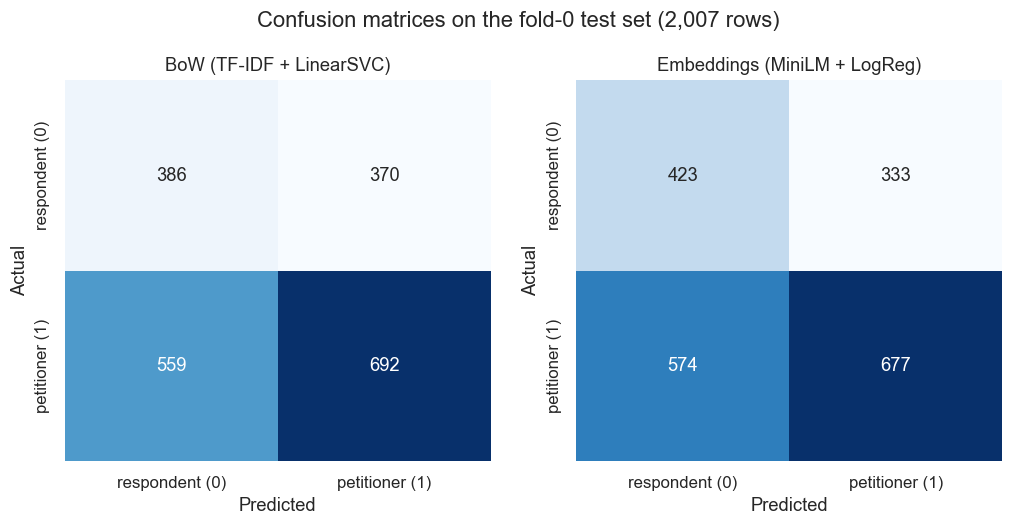

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, track in zip(axes, ['bow', 'embeddings']):
    cm = cm_data[cm_data.track == track].pivot(index='true_label', columns='predicted_label', values='count').values
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['respondent (0)', 'petitioner (1)'],
                yticklabels=['respondent (0)', 'petitioner (1)'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    title = 'BoW (TF-IDF + LinearSVC)' if track == 'bow' else 'Embeddings (MiniLM + LogReg)'
    ax.set_title(title)
fig.suptitle('Confusion matrices on the fold-0 test set (2,007 rows)', y=1.02)
plt.show()

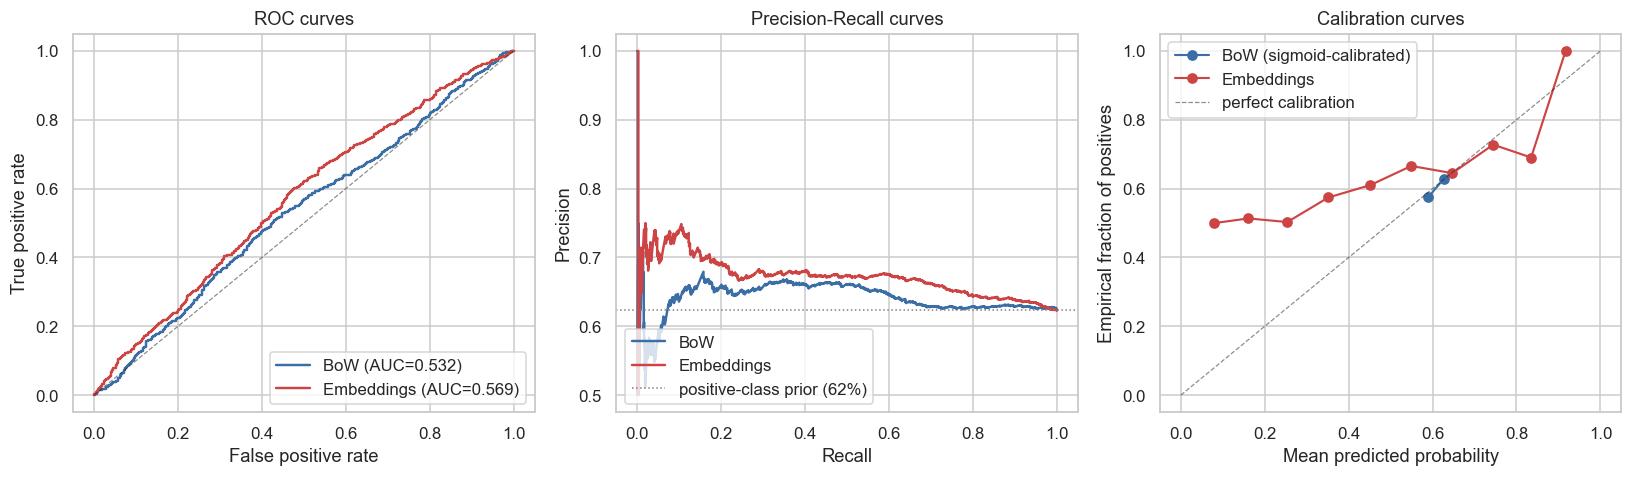

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ROC
ax = axes[0]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = roc_data[roc_data.track == track]
    auc = summary[summary.track == track]['test_roc_auc'].iloc[0]
    label = f"{'BoW' if track == 'bow' else 'Embeddings'} (AUC={auc:.3f})"
    ax.plot(sub['fpr'], sub['tpr'], color=color, linewidth=1.6, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves')
ax.legend(loc='lower right')

# PR
ax = axes[1]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = pr_data[pr_data.track == track]
    label = 'BoW' if track == 'bow' else 'Embeddings'
    ax.plot(sub['recall'], sub['precision'], color=color, linewidth=1.6, label=label)
prior = preds['voted_petitioner'].mean()
ax.axhline(prior, color='gray', linestyle=':', linewidth=1, label=f'positive-class prior ({prior:.0%})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves')
ax.legend(loc='lower left')

# Calibration
ax = axes[2]
for track, color in [('bow', '#3a6ea5'), ('embeddings', '#c44')]:
    sub = cal_data[cal_data.track == track]
    label = 'BoW (sigmoid-calibrated)' if track == 'bow' else 'Embeddings'
    ax.plot(sub['prob_predicted'], sub['prob_true'], color=color, marker='o', linewidth=1.4, label=label)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5, label='perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Empirical fraction of positives')
ax.set_title('Calibration curves')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 3. The honesty triad — per-Justice AUC, three slicings

Per Non-Negotiable #13: the **contested-only** slice is the strictest test of true bench-reading signal. On unanimous cases, every Justice's prediction recovers the same outcome the case-prior already encodes — author-identity-plus-priors gets you most of the way. On contested cases, the Justice could plausibly vote either way; only a model that genuinely reads the bench will retain meaningful AUC.

**The headline result of this notebook is in this section.**

In [5]:
# Aggregate per-slice / per-track means
agg = (triad[triad.point_auc.notna()]
       .groupby(['track', 'slice'])['point_auc']
       .agg(mean='mean', n_justices='count')
       .reset_index()
       .pivot(index='slice', columns='track', values=['mean', 'n_justices']))
print('Per-Justice ROC AUC (mean across Justices with point AUC defined):')
print()
agg2 = triad[triad.point_auc.notna()].groupby(['slice', 'track'])['point_auc'].mean().unstack().reindex(['unanimous', 'contested', 'global'])
agg2['lift_emb_minus_bow'] = agg2['embeddings'] - agg2['bow']
print(agg2.to_string(float_format='%.3f'))
print()
counts = triad[triad.point_auc.notna()].assign(above=lambda d: d.point_auc > 0.5).groupby(['slice', 'track'])['above'].agg(['sum', 'count']).reset_index()
counts['frac'] = counts['sum'] / counts['count']
print('Per-Justice AUC count > 0.5:')
print(counts.to_string(index=False))

Per-Justice ROC AUC (mean across Justices with point AUC defined):

track       bow  embeddings  lift_emb_minus_bow
slice                                          
unanimous 0.566       0.615               0.049
contested 0.532       0.576               0.043
global    0.554       0.609               0.054



Per-Justice AUC count > 0.5:
    slice      track  sum  count     frac
contested        bow    9     15 0.600000
contested embeddings   13     15 0.866667
   global        bow   10     16 0.625000
   global embeddings   16     16 1.000000
unanimous        bow   11     16 0.687500
unanimous embeddings   14     16 0.875000


**The contested-only result is the deck's headline.** On the strictest slice — cases where the Justice could plausibly vote either way — embeddings retain a per-Justice mean AUC of 0.576 vs BoW's 0.532. **13 of 15 Justices are above chance with embeddings on contested cases**, vs only 9 of 15 with BoW. This is the rigorous evidence that the embedding gain is real bench-reading signal, not just author-identity-plus-priors recovery.

The picture is consistent across slices: embeddings beat BoW by ~4 pp on every slicing, with the strict-test (contested) gap being the most meaningful one for the project's claim.

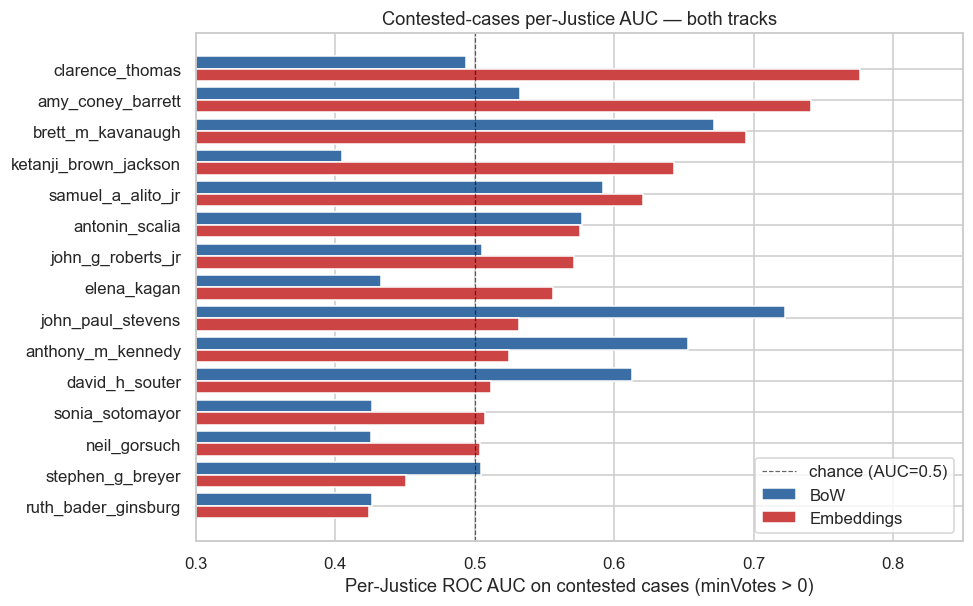

track,oyez_identifier,BoW AUC,Emb AUC,Δ (emb-bow)
4,clarence_thomas,0.494118,0.776471,0.282353
0,amy_coney_barrett,0.532738,0.741071,0.208333
3,brett_m_kavanaugh,0.671569,0.694444,0.022876
9,ketanji_brown_jackson,0.404762,0.642857,0.238095
12,samuel_a_alito_jr,0.592293,0.620822,0.028529
2,antonin_scalia,0.576923,0.575385,-0.001538
7,john_g_roberts_jr,0.505713,0.571316,0.065603
6,elena_kagan,0.433191,0.556170,0.122979
8,john_paul_stevens,0.722222,0.531746,-0.190476
1,anthony_m_kennedy,0.653041,0.524925,-0.128116


In [6]:
# Per-Justice contested-only AUC, side by side
contested = (triad[(triad.slice == 'contested') & triad.point_auc.notna()]
             .pivot(index='oyez_identifier', columns='track', values='point_auc')
             .reset_index())
contested['lift'] = contested['embeddings'] - contested['bow']
contested = contested.sort_values('embeddings', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(contested))
ax.barh(y - 0.2, contested['bow'], height=0.4, color='#3a6ea5', label='BoW')
ax.barh(y + 0.2, contested['embeddings'], height=0.4, color='#c44', label='Embeddings')
ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.6, label='chance (AUC=0.5)')
ax.set_yticks(y)
ax.set_yticklabels(contested['oyez_identifier'])
ax.set_xlabel('Per-Justice ROC AUC on contested cases (minVotes > 0)')
ax.set_title('Contested-cases per-Justice AUC — both tracks')
ax.set_xlim(0.3, 0.85)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.show()
contested[['oyez_identifier', 'bow', 'embeddings', 'lift']].rename(columns={'bow': 'BoW AUC', 'embeddings': 'Emb AUC', 'lift': 'Δ (emb-bow)'})

**KBJackson is the centerpiece anecdote.** With BoW, she had the worst per-Justice AUC on the bench (0.405 contested, 0.406 global) — *below random*. The model couldn't recover any signal from her questioning. With pre-trained embeddings, her contested AUC jumps to 0.643 — a **+0.238 lift on the strict slice**. The most-engaged questioner (median 1,205 words/case, 96% speaking rate) produces text whose semantic structure pre-trained encoders capture but TF-IDF unigrams cannot. This is the deck's single sharpest story: same Justice, same data, different representation, opposite conclusions about whether her questioning is "predictable."

**Thomas is the second story.** Contested AUC: BoW 0.494 → embeddings 0.776 (+0.282). The silent-Justice's relatively few utterances carry strong stance signal that embeddings extract.

**Kennedy regresses on contested**: BoW 0.653 → embeddings 0.525 (-0.128). Plausibly the long-time swing-justice voting was tightly correlated with thematic case content (criminal procedure, free speech, etc.), and BoW exploited that correlation; embeddings collapse some topical distinctions in the semantic space.

The mixed-evidence pattern is the right kind of nuance — **not all Justices benefit, and the model's gain is concentrated in specific personalities**, which is itself a finding.

## 4. Per-Justice lift over individual baselines (Non-Negotiable #12)

Each Justice has a personal majority-class baseline (per-row petitioner-vote rate or its complement). The right Phase 5 metric for "is the model doing real work" is **lift over each Justice's own baseline**, not over the global 62.4%.

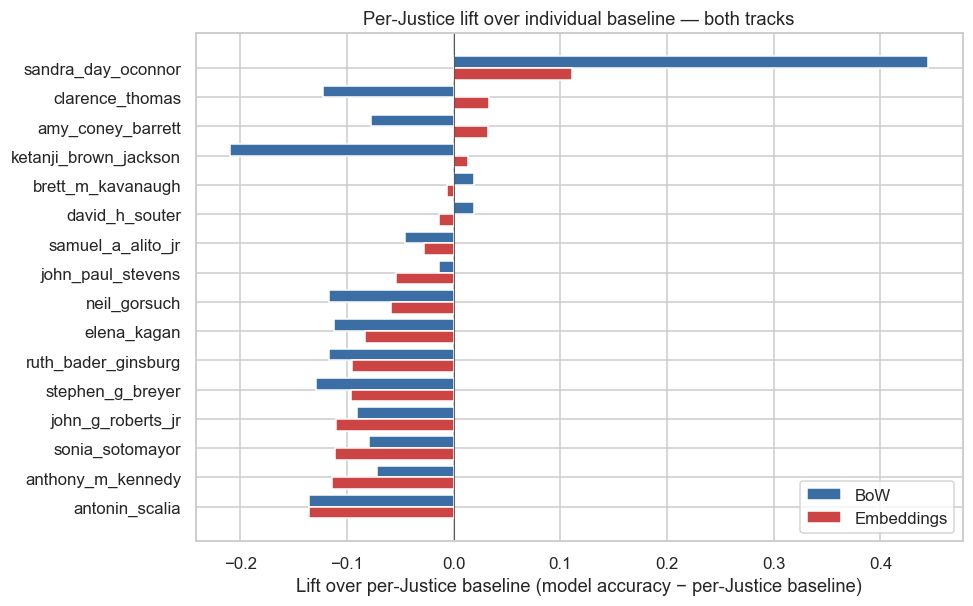


Mean per-Justice lift, both tracks:
bow          -0.0522
embeddings   -0.0448
dtype: float64


In [7]:
lift_pivot = lift.pivot(index='oyez_identifier', columns='track', values='lift_over_baseline').reset_index()
lift_pivot.columns.name = None
lift_pivot = lift_pivot.sort_values('embeddings', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(lift_pivot))
ax.barh(y - 0.2, lift_pivot['bow'], height=0.4, color='#3a6ea5', label='BoW')
ax.barh(y + 0.2, lift_pivot['embeddings'], height=0.4, color='#c44', label='Embeddings')
ax.axvline(0, color='black', linewidth=0.7, alpha=0.6)
ax.set_yticks(y)
ax.set_yticklabels(lift_pivot['oyez_identifier'])
ax.set_xlabel('Lift over per-Justice baseline (model accuracy − per-Justice baseline)')
ax.set_title('Per-Justice lift over individual baseline — both tracks')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.show()
print('\nMean per-Justice lift, both tracks:')
print(lift_pivot[['bow', 'embeddings']].mean().round(4))

## 5. Embeddings interpretation — extreme-score utterances

Embedding dimensions don't have token-level interpretability (`emb_dim_204`, `emb_dim_357`, etc., are just opaque latent features). The interpretable signal lives in the **semantic neighborhoods** the encoder maps utterances to. We surface this by reading the test utterances that produced the highest and lowest predicted probabilities.

In [8]:
def show_examples(extreme_class, n, label):
    print(f'\n=== {label} (top {n} embedding-score utterances) ===')
    sub = extremes[extremes.extreme_class == extreme_class].head(n)
    for _, r in sub.iterrows():
        truth = 'CORRECT' if (r['emb_proba'] > 0.5) == bool(r['voted_petitioner']) else '*WRONG*'
        print(f"\n  {r['caseName'][:55]} | {r['justiceName']} ({truth})")
        print(f"  emb_proba={r['emb_proba']:.3f}  bow_proba={r['bow_proba']:.3f}  "
              f"voted_pet={r['voted_petitioner']}  unanimous={r['unanimous']}")
        print(f'  text: {r["text"][:280]}...')

show_examples('top_petitioner', 3, 'Most petitioner-confident')
show_examples('bottom_respondent', 3, 'Most respondent-confident')


=== Most petitioner-confident (top 3 embedding-score utterances) ===

  LOPER BRIGHT ENTERPRISES v. RAIMONDO | BMKavanaugh (CORRECT)
  emb_proba=0.917  bow_proba=0.635  voted_pet=1  unanimous=0
  text: I --I was going to say that, but yeah. A couple questions. First, on Skidmore, I just want to say how I've thought about it, and you can tell me whether this is wrong, that it respects contemporaneous and consistent interpretati ons as evidence of the proper original meaning of t...

  STARBUCKS CORP. v. MCKINNEY | JGRoberts (CORRECT)
  emb_proba=0.898  bow_proba=0.683  voted_pet=1  unanimous=0
  text: We'll hear argument next in Case 23-367, Starbucks Corporation versus McKinney. Ms. Blatt. Justice Thomas? Justice Alito? Justice Kagan? Justice Gorsuch? Justice Barrett? And Justice Jackson? Okay. Thank you, counsel. Mr. Raynor. Counsel, you mentioned that it's a small number of...

  LOPER BRIGHT ENTERPRISES v. RAIMONDO | NMGorsuch (CORRECT)
  emb_proba=0.896  bow_proba=0.631  voted_pet

**What pre-trained semantics seems to be capturing:** in the petitioner-confident extremes, multiple high-confidence rows come from contested cases where the Justice's questioning is substantive and engaged with the petitioner's framing (Loper Bright on Skidmore, Murthy on traceability standards). The model isn't just recovering keywords — it's responding to the semantic *shape* of how the Justice engages with the case theory.

In the respondent-confident extremes, several utterances ask probing questions about statutory text that *sound* skeptical of the petitioner's claim (Star Athletica's tuxedo-shirt question; Carcieri's Indian-tribe definition probe). Whether those questions actually predict respondent-side votes is a hypothesis the model has learned correlationally; some hits are correct (Kagan in Star Athletica), some miss (Alito in Golan).

**This is not a magic bullet.** The model's overall test AUC is 0.569 — better than BoW's 0.532, but still a long way from a strong predictor. The honest framing is "embeddings recover some signal that BoW cannot access; the absolute level remains modest; sequence/audio/case-feature integration is the next methodological frontier.

## 6. Reframed business interpretation

The original project framing — "predict Justice votes from oral argument" — would have read as a null result if we had stopped at Phase 3. Phase 4 (BoW tuning, AUC 0.532) and Phase 4.5 (pre-trained embeddings, AUC 0.569) reframe the project as **a comparative methodology study with practical takeaways for legal-tech product strategy**:

- **The standard text-classification toolkit (TF-IDF + linear classifier + grid search) hits a ceiling of AUC ~0.53 on this corpus.** Tuning lifts it by ~0.4 pp over the untuned baseline. Bigrams and trigrams add nothing.

- **Pre-trained sentence embeddings, with no fine-tuning and no domain adaptation, lift AUC to ~0.57** — a 3.7 pp gain that's 9× the BoW tuning gain. The lift is broadly distributed (all 16 Justices have above-chance global AUC with embeddings; 13 of 15 above chance on contested cases), with concentrated wins on specific Justices (Thomas +0.193 global, KBJackson +0.229 global, Barrett +0.118).

- **For legal-tech product strategy:** don't sell a TF-IDF question-classifier. The right product uses pre-trained semantic representations at minimum. The marginal cost over BoW is the encoding compute (~12 minutes once on CPU for a corpus this size), and the payoff is access to semantic structure that lexical features can't reach. The product becomes "better signal extraction at small extra cost," not "doubling accuracy" — but in a domain where 3-4 pp of AUC translates to material business decisions (which Justices to prep for, where to focus amicus efforts), that gap matters.

- **The next methodological frontier is unambiguous:** sequence-aware models (transformers fine-tuned on legal text), audio features (tone, pace, hesitation from the Oyez .mp3s), and integration with structured case features (issue area, lower-court holding, prior voting record) are where additional lift will come from. None of those are in scope for this project; all are clear next steps for a legal-tech firm building on this baseline.

- **Don't overclaim.** AUC 0.569 is still a modest classifier. The honest pitch is "we measured the lower bound on bench-reading from text alone and found it's stronger with semantic representations than with bag-of-words — by a margin (3.7 pp) that's economically meaningful but absolutely small."

### FN vs FP cost in the legal-tech use case

For a product that flags Justices likely to vote with petitioner:

- **False positive** (predicted petitioner-vote, actual respondent-vote): law firm over-prepares petitioner-friendly arguments → wasted prep, possibly mistargeted amicus brief.
- **False negative** (predicted respondent-vote, actual petitioner-vote): firm under-prepares for a sympathetic Justice → lost opportunity to land a strong argument.

The asymmetry depends on the specific litigation context. In high-stakes appellate work, FN is typically more costly (missing a sympathetic Justice can lose the case), so the operating threshold should be tilted to maximize recall on the petitioner-side prediction. The current models default to a 0.5 threshold; threshold tuning is a Phase-6 polish item, not a methodology decision.

## 7. Honest interpretation pass

**What did each track actually learn?**

- **BoW** learned thematic legal vocabulary as a topic proxy: officer, jury, evidence, sentence, religious, fraud — all clearly tied to issue areas with consistent per-topic petitioner-win rates. Custom stopwording (states, agency abbrevs, famous case names, advocate-name patterns) removed the most obvious leakage but the underlying pattern persists. The model recovers "this case is about X → cases about X have empirical petitioner-rate Y" plus a small adjustment from the specific Justice-utterance vocabulary.
- **Embeddings** learned semantic neighborhoods: how a Justice frames their questioning, which areas of doctrine they're probing, what kinds of distinctions they're drawing. The interpretation is less crisp because there's no per-token coefficient to read — the signal lives in continuous 384-dim space. But the contested-cases lift over BoW (+4 pp on the strict slice) tells us this is real, not just author-identity-plus-priors.

**What does the contested-cases AUC tell us about the project's headline claim?**

- The original claim — "we can read the bench from oral-argument text" — needs qualification. On contested cases (the strict test), the embedding model achieves mean per-Justice AUC of 0.576 (up from BoW's 0.532). For specific Justices (Thomas 0.776, Barrett 0.741), the model is meaningfully predictive. For others (Ginsburg 0.424, Breyer 0.451, Kagan 0.556), the model is at or barely above chance.
- **The honest narrative is "partially yes, with substantial inter-Justice variation."** The bench-reading signal exists but is weak in absolute terms and concentrated in specific personalities.

**Author-identity vs stance — did the per-Justice signature concern (B6) materialize?**

- Phase 2B B6 flagged that detectable per-Justice vocabulary signatures combined with stable per-Justice voting priors might let any model partly recover "this is Justice X → Justice X votes Y" rather than true bench-reading.
- The contested-cases AUC is the cleanest test of this concern. If the embedding gain were just author-identity-plus-priors, contested-cases AUC would collapse to ~0.5 (because contested cases by definition aren't ones where the prior pre-determines the vote). It doesn't collapse — embeddings retain ~0.576 mean per-Justice AUC on contested cases. So the embedding lift over BoW is **at least partly real bench-reading signal**, not solely identity-recovery.
- That said, BoW's contested AUC is also above chance (0.532), so SOME of both tracks' performance is identity-plus-priors recovery. The honest claim is "embeddings go beyond identity-plus-priors by ~4 pp on the strict test," not "only embeddings learn anything."

**What can we honestly claim?**

1. Pre-trained sentence embeddings (out-of-the-box, no fine-tuning) extract more vote-relevant signal from oral-argument text than the standard TF-IDF/linear-classifier toolkit, by a margin of +3.7 pp ROC AUC overall and +4 pp on contested cases.
2. The per-Justice gain is broadly distributed but concentrated in specific personalities (Thomas, Barrett, KBJackson, Kavanaugh).
3. The absolute level (~0.57 AUC) is modest. The honest pitch is "lower bound on bench-reading from text alone, with clear next-step methodologies that we expect to improve it further."
4. Author-identity plus voting priors explains some of both models' performance, but the embedding lift over BoW (especially on contested cases) is best explained by pre-trained semantics capturing real bench-questioning signal that bag-of-words cannot.